In [1]:
import sys
import os
import pandas as pd
# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.dgp import GaussianNetwork
from src.metrics import Rejection, FalseRejection, rv_coefficient
from src.methods import RVPermutationTest
from src.simulation_functions import run_simulation
from src.analyse_functions import aggregate_results
import re
from src.plot_functions import plot_grid, plot_with_bands


In [2]:
# two egde variances 0.5 and 1, only Falserejection, 10k nsim, name=simulation_results_20260122_1816.csv"
# one edge var at 1, 20k nsim, name=simulation_results_20260123_1022.csv
# sigma 05, 099 simulation_results_20260124_2058
results = pd.read_csv("simulation_results_20260125_1410.csv") 

In [3]:
results['method'] = results['args'].apply(lambda x: re.search(r"'method':.*?\.(\w+?)(?=Test)", x).group(1).lower())
results['sigma'] = results['args'].apply(lambda x: re.search(r"'sigma':\s*(\d+\.?\d*)", x).group(1))

In [4]:
# extract df based on confid

# based on sigma
results_null = results[(results['sigma'] == '0')].copy()
results_alt_01 = results[(results['sigma'] == '0.1')].copy()
results_alt_001 = results[(results['sigma'] == '0.01')].copy()

#based on sigma + method
results_llk_ratio_null = results[(results['method'] == 'llkratio') & (results['sigma'] == '0')].copy()
results_llk_ratio_alt_001 = results[(results['method'] == 'llkratio') & (results['sigma'] == '0.01')].copy()
results_llk_ratio_alt_01 = results[(results['method'] == 'llkratio') & (results['sigma'] == '0.1')].copy()

results_rv_null = results[(results['method'] == 'rvpermutation') & (results['sigma'] == '0')].copy()
results_rv_alt_001 = results[(results['method'] == 'rvpermutation') & (results['sigma'] == '0.01')].copy()
results_rv_alt_01 = results[(results['method'] == 'rvpermutation') & (results['sigma'] == '0.1')].copy()

In [5]:
# for the null extract the false rejection to study type I error
agg_null = aggregate_results(results_null, y_axis='FalseRejection', x_axis='n', factors=['edge_var', 'k', 'method'])

# for alternative extract the true rejection to study power
agg_alt_001 = aggregate_results(results_alt_001, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_alt_01 = aggregate_results(results_alt_01, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])

In [6]:
agg_llk_ratio_null = aggregate_results(results_llk_ratio_null, y_axis='FalseRejection', x_axis='n', factors=['edge_var', 'k'])
agg_rv_null = aggregate_results(results_rv_null, y_axis='FalseRejection', x_axis='n', factors=['edge_var', 'k'])

agg_llk_ratio_alt_001 = aggregate_results(results_llk_ratio_alt_001, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k'])
agg_llk_ratio_alt_01 = aggregate_results(results_llk_ratio_alt_01, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k'])

agg_rv_alt_001 = aggregate_results(results_rv_alt_001, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k'])
agg_rv_alt_01 = aggregate_results(results_rv_alt_01, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k'])

## Plots

**Ensure type I error is controlled at 5%**

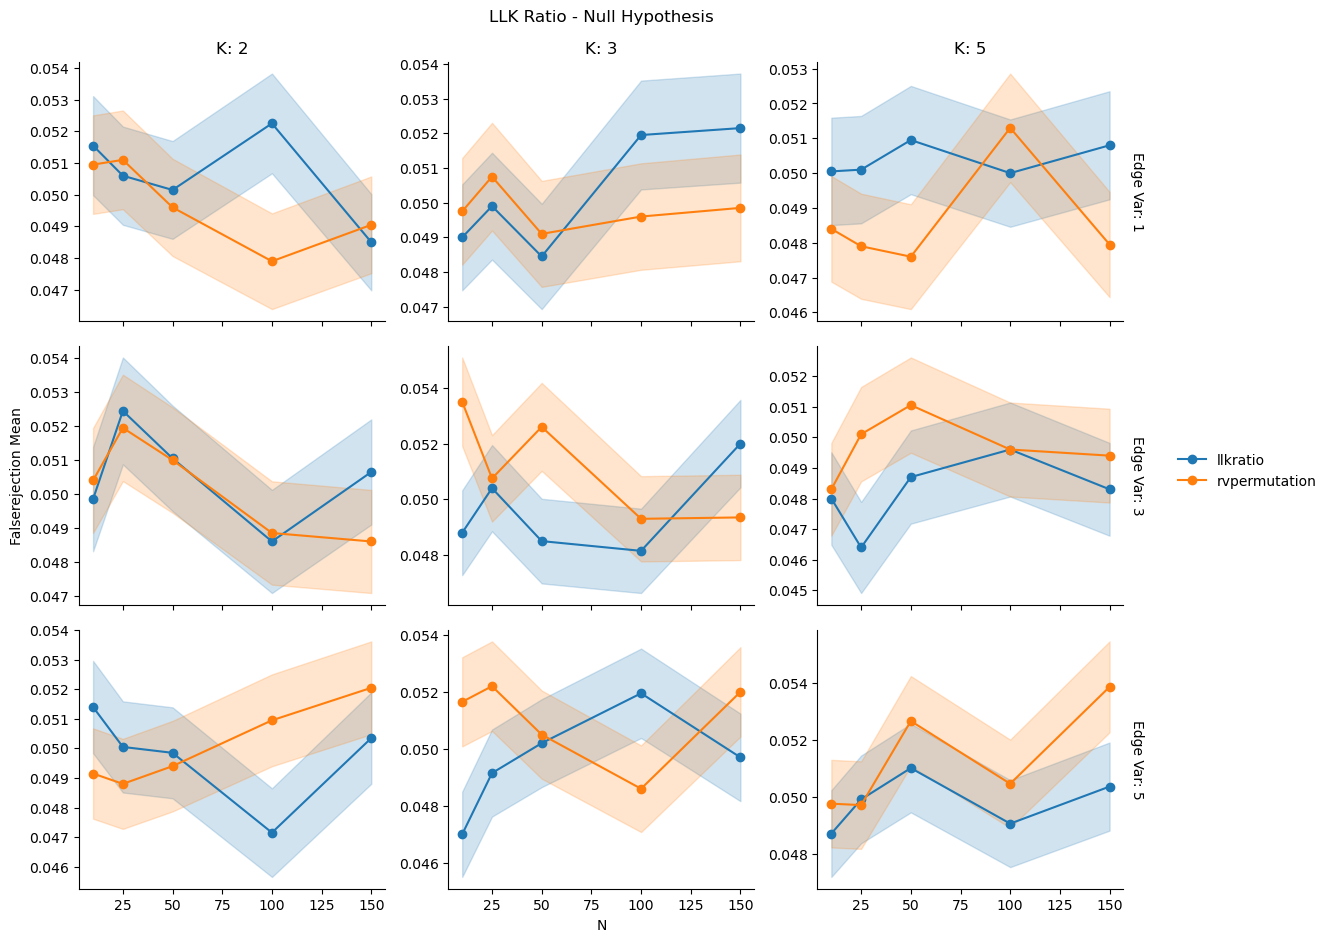

In [7]:
plot_grid(
        grouped_stats=agg_null,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='FalseRejection_mean',
        factors=['method', 'k', 'edge_var'],
        height=3,
        se_bands='FalseRejection_sem',
        share_x=True,
        share_y=False,
        title='LLK Ratio - Null Hypothesis'
    )

**Study Power**

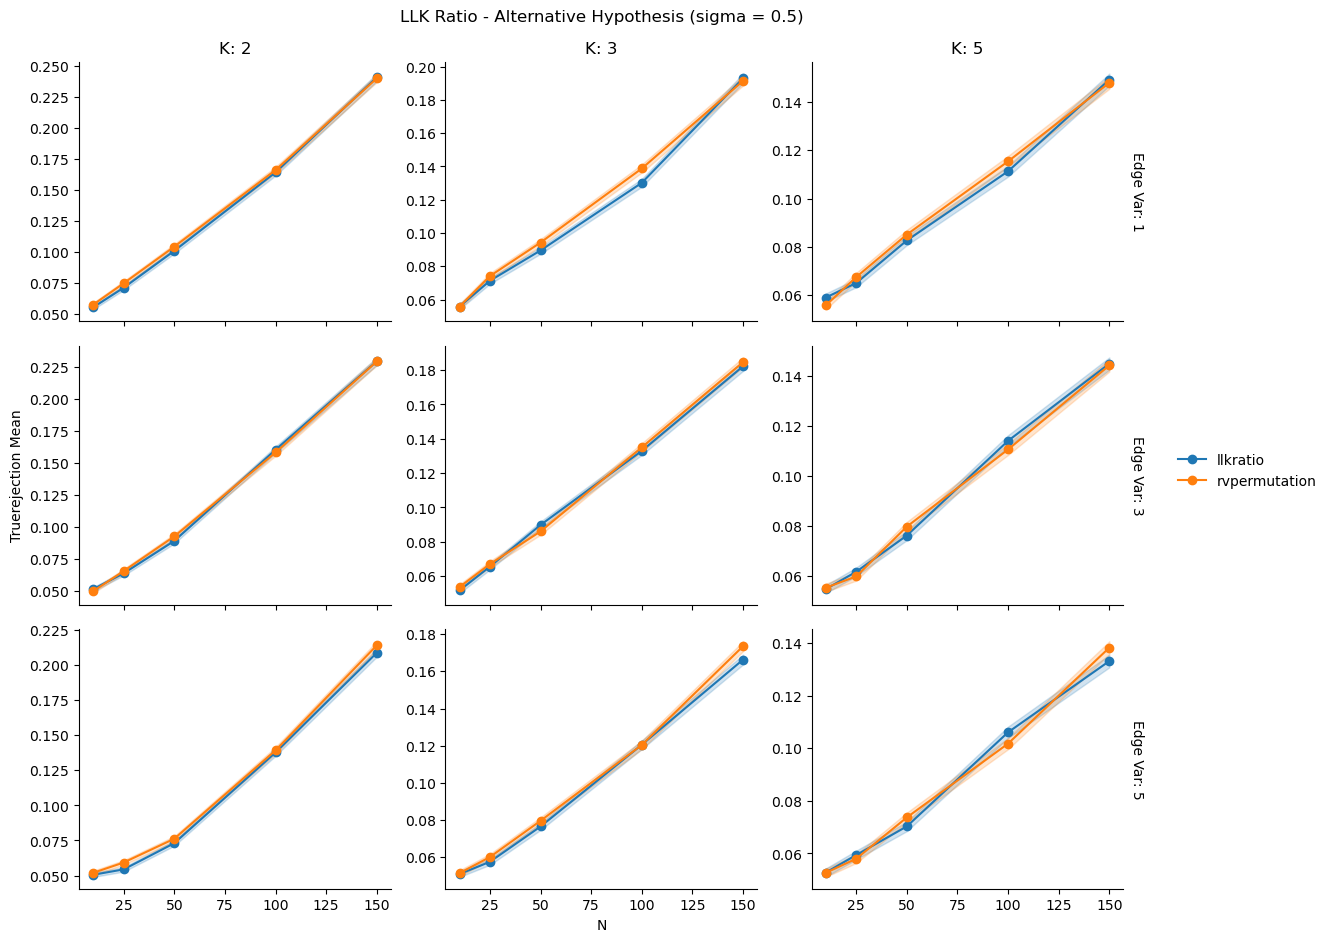

In [ ]:
plot_grid(
        grouped_stats=agg_alt_01,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'k', 'edge_var'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='LLK Ratio - Alternative Hypothesis (sigma = 0.01)'
    )

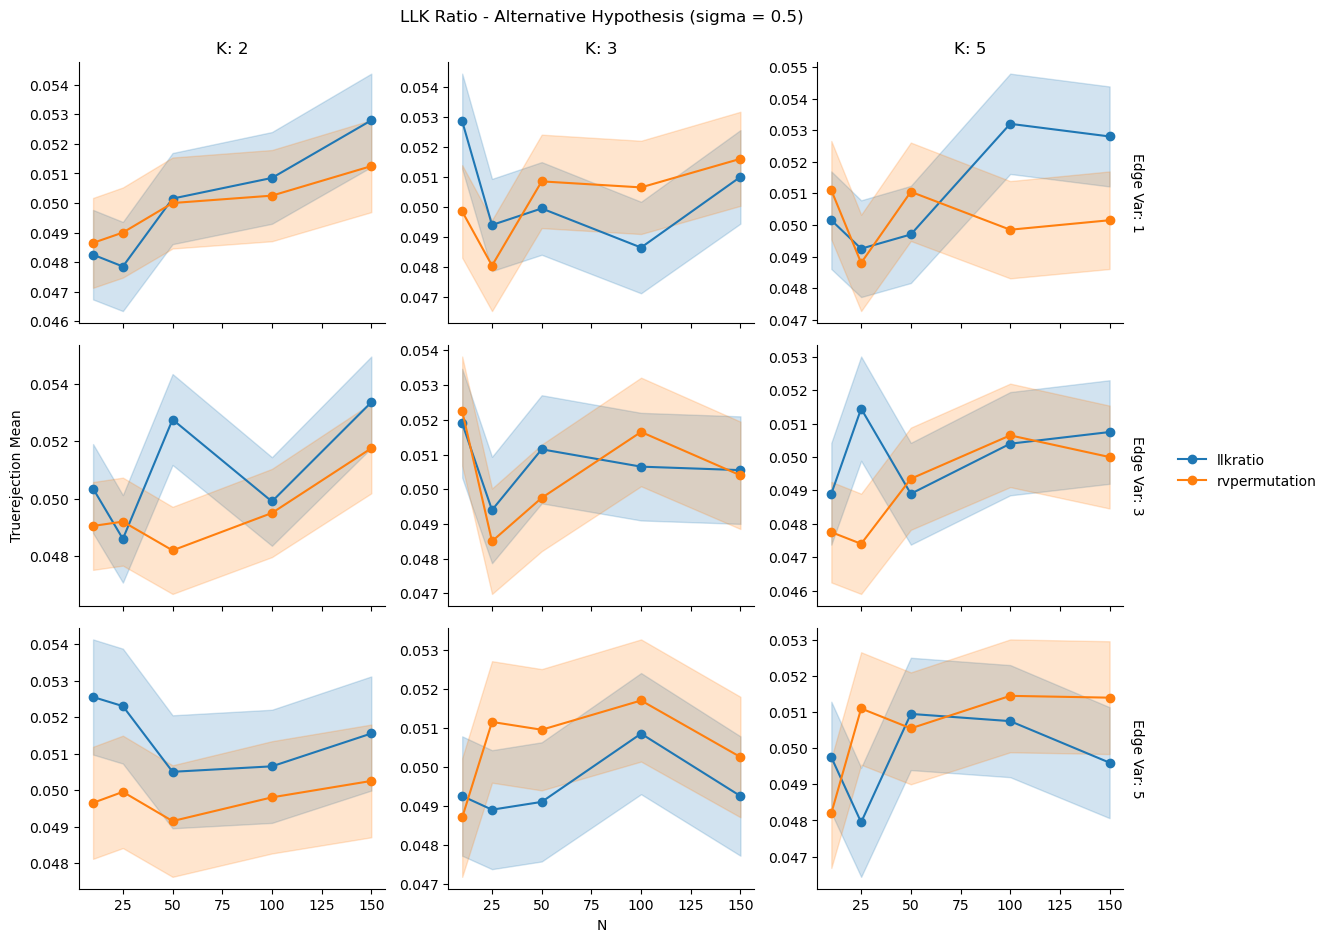

In [9]:
plot_grid(
        grouped_stats=agg_alt_001,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'k', 'edge_var'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='LLK Ratio - Alternative Hypothesis (sigma = 0.5)'
    )

In [10]:
plot_grid(
        grouped_stats=agg_llk_ratio_alternative,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='LLK Ratio - Alternative Hypothesis (sigma-0.5)'
    )

plot_grid(
        grouped_stats=agg_rv_alternative,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='RV permutation - Alternative Hypothesis (sigma-0.5)'
    )

NameError: name 'agg_llk_ratio_alternative' is not defined